In [1]:
import pandas as pd
import glob
import json
import matplotlib.pyplot as plt

In [2]:
files = glob.glob('data/202507-citibike-tripdata/*.csv')
files

['data/202507-citibike-tripdata\\202507-citibike-tripdata_1.csv',
 'data/202507-citibike-tripdata\\202507-citibike-tripdata_2.csv',
 'data/202507-citibike-tripdata\\202507-citibike-tripdata_3.csv',
 'data/202507-citibike-tripdata\\202507-citibike-tripdata_4.csv',
 'data/202507-citibike-tripdata\\202507-citibike-tripdata_5.csv']

In [3]:
clean_chunks = []

for f in files:
    for chunk in pd.read_csv(
        f,
        chunksize=200000,
        low_memory=False,
        dtype={'start_station_id': 'string', 'end_station_id': 'string'}
    ):
        chunk['started_at'] = pd.to_datetime(chunk['started_at'], errors='coerce')
        chunk['ended_at'] = pd.to_datetime(chunk['ended_at'], errors='coerce')
        chunk = chunk.dropna(subset=['started_at','ended_at'])
        d = (chunk['ended_at'] - chunk['started_at']).dt.total_seconds()
        chunk = chunk[(d >= 60) & (d <= 10800)]
        chunk = chunk[(chunk['started_at'].dt.year == 2025) & (chunk['started_at'].dt.month == 7)]
        chunk['date'] = chunk['started_at'].dt.date
        chunk['hour'] = chunk['started_at'].dt.hour
        clean_chunks.append(chunk)

trips_clean = pd.concat(clean_chunks, ignore_index=True)

In [4]:
with open("data/NYC_Weather_July2025.txt") as f:
    weather_json = json.load(f)

In [5]:
weather_days = weather_json['days']
weather_rows = []

for day in weather_days:
    date = day['datetime']
    for h in day['hours']:
        weather_rows.append({
            'date': date,
            'hour': int(h['datetime'].split(':')[0]),
            'temp': h['temp'],
            'feelslike': h['feelslike'],
            'precip': h['precip'],
            'cloudcover': h['cloudcover'],
            'conditions': h['conditions']
        })

weather = pd.DataFrame(weather_rows)
weather['date'] = pd.to_datetime(weather['date']).dt.date

In [6]:
merged = trips_clean.merge(weather, on=['date','hour'], how='left')

merged_trips = trips_clean.merge(weather, on=['date','hour'], how='left')

rides_by_hour = (
    trips_clean
    .groupby(['date','hour'])
    .size()
    .reset_index(name='rides')
)

merged_hourly = rides_by_hour.merge(weather, on=['date','hour'], how='left')

In [7]:
merged.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,hour,temp,feelslike,precip,cloudcover,conditions
0,BF31E940F7D80958,electric_bike,2025-07-11 18:42:36.430,2025-07-11 18:46:37.195,N 6 St & Bedford Ave,5379.10,Broadway & Berry St,5164.05,40.717452,-73.958509,40.710361,-73.965304,member,2025-07-11,18,80.6,83.3,0.0,27.9,Partially cloudy
1,0DF0EDCFF6452D83,electric_bike,2025-07-12 19:11:05.558,2025-07-12 19:20:05.429,Huron St & Franklin St,5869.04,Broadway & Berry St,5164.05,40.732660,-73.958260,40.710361,-73.965304,member,2025-07-12,19,78.2,78.2,0.0,34.2,Partially cloudy
2,9AFD3BA9E53733E7,electric_bike,2025-07-02 19:38:18.759,2025-07-02 20:10:05.899,Macon St & Howard Ave,4408.07,Stockholm St & Wilson Ave,4824.03,40.684520,-73.920110,40.699304,-73.923044,casual,2025-07-02,19,79.8,79.8,0.0,65.0,Partially cloudy
3,146A0E14AC873008,classic_bike,2025-07-04 22:03:19.382,2025-07-04 22:37:20.104,Clark St & Henry St,4789.03,Marcus Garvey Blvd & Macon St,4278.03,40.697601,-73.993446,40.682601,-73.938037,member,2025-07-04,22,77.4,77.4,0.0,10.5,Clear
4,54D1DCA4B21AC7C1,electric_bike,2025-07-07 18:20:14.380,2025-07-07 18:36:38.257,N 6 St & Bedford Ave,5379.10,Stockholm St & Wilson Ave,4824.03,40.717452,-73.958509,40.699304,-73.923044,member,2025-07-07,18,82.2,86.8,0.0,42.4,Partially cloudy


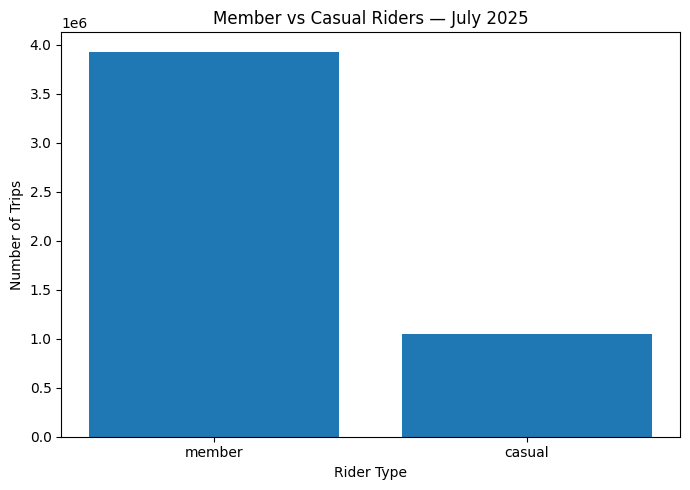

In [8]:
counts = trips_clean['member_casual'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(counts.index, counts.values)
plt.xlabel("Rider Type")
plt.ylabel("Number of Trips")
plt.title("Member vs Casual Riders — July 2025")
plt.tight_layout()
plt.show()

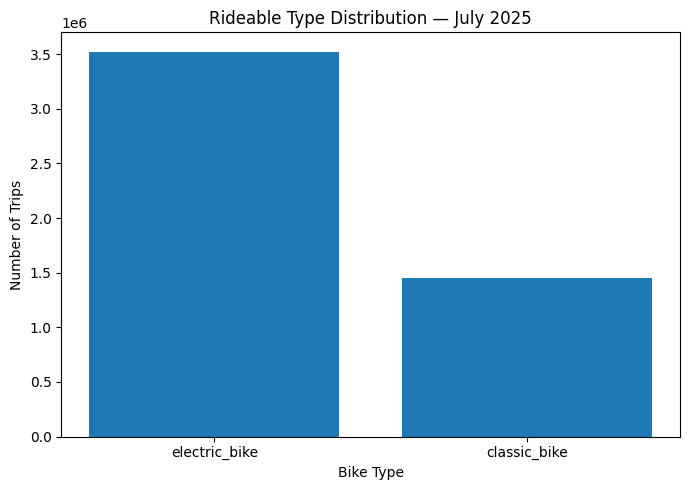

In [9]:
types = trips_clean['rideable_type'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(types.index, types.values)
plt.xlabel("Bike Type")
plt.ylabel("Number of Trips")
plt.title("Rideable Type Distribution — July 2025")
plt.tight_layout()
plt.show()

In [10]:
hourly_avg = (
    trips_clean
    .groupby(['date','hour'])
    .size()
    .groupby('hour')
    .mean()
)

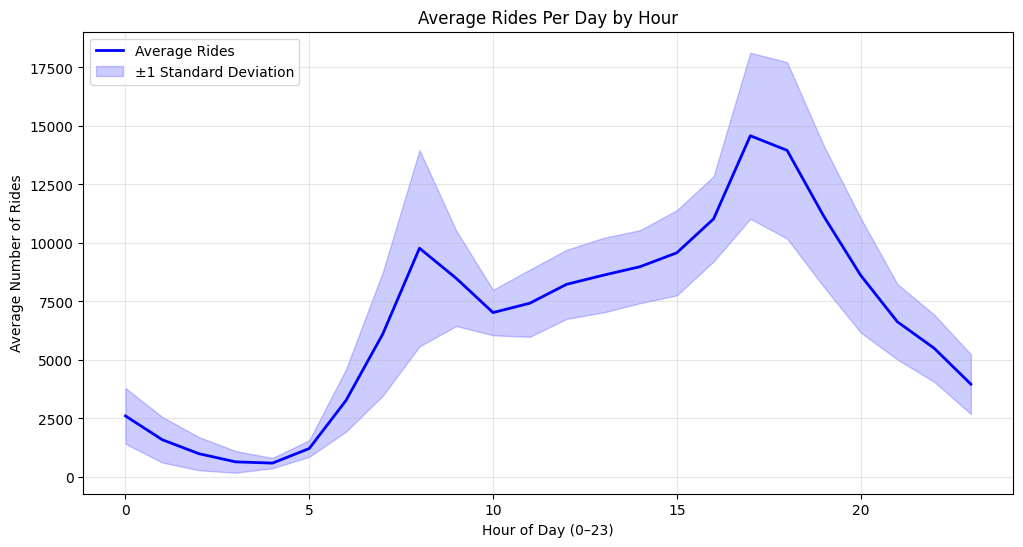

In [11]:
hourly_stats = merged_hourly.groupby('hour')['rides'].agg(['mean','std']).reset_index()

plt.figure(figsize=(12,6))

plt.plot(hourly_stats['hour'], hourly_stats['mean'], color='blue', linewidth=2, label='Average Rides')

plt.fill_between(
    hourly_stats['hour'],
    hourly_stats['mean'] - hourly_stats['std'],
    hourly_stats['mean'] + hourly_stats['std'],
    color='blue',
    alpha=0.2,
    label='±1 Standard Deviation'
)

plt.title("Average Rides Per Day by Hour")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Average Number of Rides")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

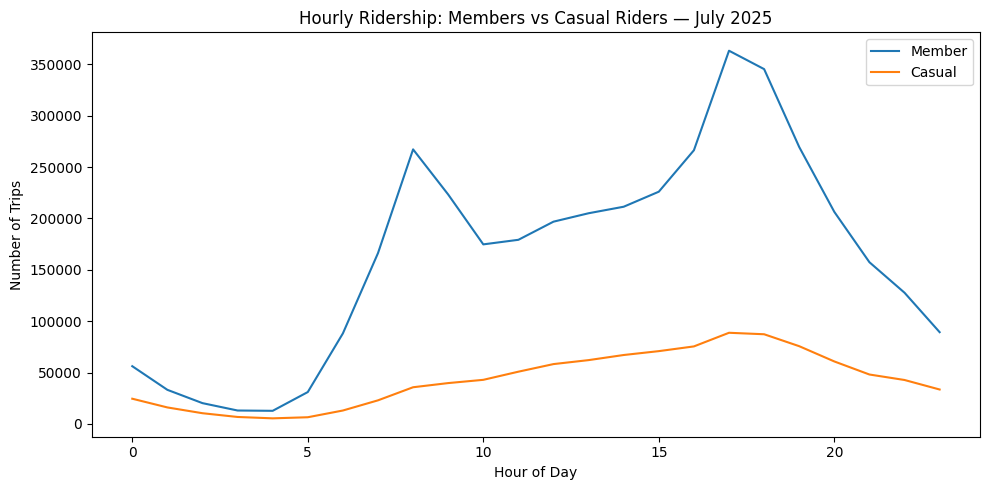

In [12]:
hourly_member = (
    merged_trips[merged_trips['member_casual'] == 'member']
    .groupby('hour')
    .size()
)

hourly_casual = (
    merged_trips[merged_trips['member_casual'] == 'casual']
    .groupby('hour')
    .size()
)

plt.figure(figsize=(10,5))
plt.plot(hourly_member.index, hourly_member.values, label='Member')
plt.plot(hourly_casual.index, hourly_casual.values, label='Casual')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Hourly Ridership: Members vs Casual Riders — July 2025")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
merged_trips['started_at'] = pd.to_datetime(merged_trips['started_at'])
merged_trips['weekday'] = merged_trips['started_at'].dt.dayofweek < 5

merged_trips[['started_at','weekday']].head()

,started_at,weekday
0,2025-07-11 18:42:36.430,True
1,2025-07-12 19:11:05.558,False
2,2025-07-02 19:38:18.759,True
3,2025-07-04 22:03:19.382,True
4,2025-07-07 18:20:14.380,True


In [14]:
merged_hourly = merged_trips.groupby(['date','hour','weekday']).agg({
    'ride_id':'count',
    'temp':'mean',
    'feelslike':'mean',
    'precip':'mean',
    'cloudcover':'mean'
}).reset_index()

merged_hourly = merged_hourly.rename(columns={'ride_id':'rides'})

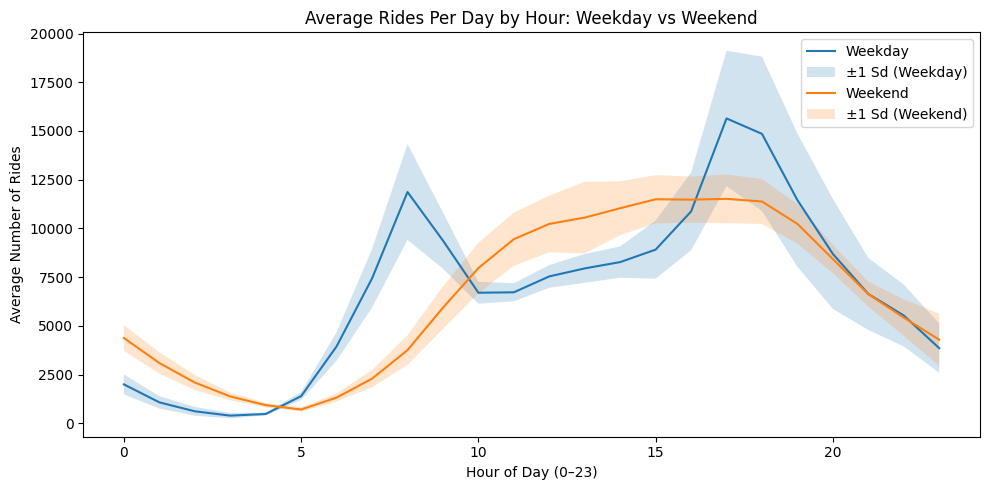

In [15]:
t = merged_trips.copy()
t['date'] = t['started_at'].dt.date
t['hour'] = t['started_at'].dt.hour
t['weekday'] = t['started_at'].dt.weekday < 5

g = t.groupby(['weekday','date','hour'])['ride_id'].size().reset_index(name='rides')
g = g.groupby(['weekday','hour'])['rides'].agg(['mean','std']).reset_index()

wd = g[g['weekday'] == True]
we = g[g['weekday'] == False]

plt.figure(figsize=(10,5))

# Weekday
plt.plot(wd['hour'], wd['mean'], label='Weekday')
plt.fill_between(wd['hour'], wd['mean'] - wd['std'], wd['mean'] + wd['std'],
                 alpha=.2, label='±1 Sd (Weekday)')

# Weekend
plt.plot(we['hour'], we['mean'], label='Weekend')
plt.fill_between(we['hour'], we['mean'] - we['std'], we['mean'] + we['std'],
                 alpha=.2, label='±1 Sd (Weekend)')

plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Average Number of Rides')
plt.title('Average Rides Per Day by Hour: Weekday vs Weekend')
plt.legend()
plt.tight_layout()
plt.show()

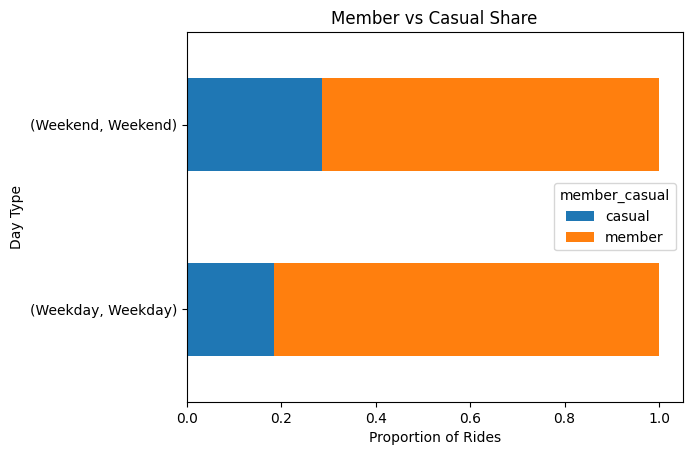

In [16]:
merged_trips['day_type'] = merged_trips['weekday'].map({
    True: 'Weekday',
    False: 'Weekend'
})

c = merged_trips.groupby(['day_type','member_casual'])['ride_id'].count()
c = c.groupby(level=0).apply(lambda x: x / x.sum())
c = c.unstack()

c.plot(kind='barh', stacked=True)
plt.xlabel('Proportion of Rides')
plt.ylabel('Day Type')
plt.title('Member vs Casual Share')
plt.show()

In [17]:
print("merged_trips shape:", merged_trips.shape)
display(merged_trips.head())

merged_trips shape: (4977167, 22)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,member_casual,date,hour,temp,feelslike,precip,cloudcover,conditions,weekday,day_type
0,BF31E940F7D80958,electric_bike,2025-07-11 18:42:36.430,2025-07-11 18:46:37.195,N 6 St & Bedford Ave,5379.10,Broadway & Berry St,5164.05,40.717452,-73.958509,...,member,2025-07-11,18,80.6,83.3,0.0,27.9,Partially cloudy,True,Weekday
1,0DF0EDCFF6452D83,electric_bike,2025-07-12 19:11:05.558,2025-07-12 19:20:05.429,Huron St & Franklin St,5869.04,Broadway & Berry St,5164.05,40.732660,-73.958260,...,member,2025-07-12,19,78.2,78.2,0.0,34.2,Partially cloudy,False,Weekend
2,9AFD3BA9E53733E7,electric_bike,2025-07-02 19:38:18.759,2025-07-02 20:10:05.899,Macon St & Howard Ave,4408.07,Stockholm St & Wilson Ave,4824.03,40.684520,-73.920110,...,casual,2025-07-02,19,79.8,79.8,0.0,65.0,Partially cloudy,True,Weekday
3,146A0E14AC873008,classic_bike,2025-07-04 22:03:19.382,2025-07-04 22:37:20.104,Clark St & Henry St,4789.03,Marcus Garvey Blvd & Macon St,4278.03,40.697601,-73.993446,...,member,2025-07-04,22,77.4,77.4,0.0,10.5,Clear,True,Weekday
4,54D1DCA4B21AC7C1,electric_bike,2025-07-07 18:20:14.380,2025-07-07 18:36:38.257,N 6 St & Bedford Ave,5379.10,Stockholm St & Wilson Ave,4824.03,40.717452,-73.958509,...,member,2025-07-07,18,82.2,86.8,0.0,42.4,Partially cloudy,True,Weekday


In [18]:
print("merged_hourly shape:", merged_hourly.shape)
display(merged_hourly.head())

merged_hourly shape: (744, 8)


,date,hour,weekday,rides,temp,feelslike,precip,cloudcover
0,2025-07-01,0,True,1748,78.2,78.2,0.000,29.4
1,2025-07-01,1,True,843,78.2,78.2,0.000,67.5
2,2025-07-01,2,True,301,77.9,77.9,0.000,53.4
3,2025-07-01,3,True,143,75.7,75.7,0.074,95.2
4,2025-07-01,4,True,254,74.5,74.5,0.051,99.0


In [19]:
merged_hourly[['rides','temp','feelslike','precip','cloudcover']].corr()

,rides,temp,feelslike,precip,cloudcover
rides,1.000000,0.500014,0.480934,-0.064069,0.005051
temp,0.500014,1.000000,0.973074,-0.066726,-0.213480
feelslike,0.480934,0.973074,1.000000,-0.064511,-0.182463
precip,-0.064069,-0.066726,-0.064511,1.000000,0.102702
cloudcover,0.005051,-0.213480,-0.182463,0.102702,1.000000


In [20]:
from sklearn.linear_model import LinearRegression

X = merged_hourly[['temp','precip','cloudcover']]
y = merged_hourly['rides']

model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
coef = model.coef_

print(f"Intercept: {intercept:.2f}")
print(f"temp: {coef[0]:.2f}")
print(f"precip: {coef[1]:.2f}")
print(f"cloudcover: {coef[2]:.2f}")

Intercept: -26175.41
temp: 402.65
precip: -3039.20
cloudcover: 16.86


In [21]:
print("Temperature has a strong positive effect on ridership, meaning warmer hours consistently lead to more rides. Precipitation shows a large negative coefficient, \nindicating that rainfall reduces ridership, although the effect can vary depending on intensity and duration. Cloud cover has a small positive effect, \nsuggesting that overcast conditions slightly increase ridership, possibly because riders avoid direct sun or heat. Overall, the model shows how \ndifferent weather factors contribute to changes in hourly ride volume.")

Temperature has a strong positive effect on ridership, meaning warmer hours consistently lead to more rides. Precipitation shows a large negative coefficient, 
indicating that rainfall reduces ridership, although the effect can vary depending on intensity and duration. Cloud cover has a small positive effect, 
suggesting that overcast conditions slightly increase ridership, possibly because riders avoid direct sun or heat. Overall, the model shows how 
different weather factors contribute to changes in hourly ride volume.


In [22]:
rain_hours = merged_hourly['precip'].gt(0).sum()
total_hours = merged_hourly.shape[0]
rain_hours / total_hours

np.float64(0.06854838709677419)

In [23]:
merged_trips.groupby(['member_casual', 'cloudcover'])['ride_id'].count().unstack()

cloudcover,0.0,4.4,7.2,8.4,10.5,12.1,12.4,12.7,14.1,15.6,...,96.7,97.3,97.5,97.9,98.2,98.9,99.0,99.1,99.2,100.0
member_casual,,,,,,,,,,,,,,,,,,,,,
casual,1590,3272,303,4822,89829,2904,6884,1187,27288,14461,...,4222,218,10313,1284,10794,107,1262,8535,281,22814
member,4708,14159,766,17898,306443,12388,32390,6553,103744,65627,...,10980,1498,38969,4919,38055,287,6086,32396,1447,88598


In [24]:
merged_trips['cloud_bin'] = pd.cut(
    merged_trips['cloudcover'],
    bins=[0,30,70,100],
    labels=['Clear','Partly Cloudy','Overcast']
)

merged_trips.groupby(['cloud_bin','member_casual'])['ride_id'].count().unstack()

member_casual,casual,member
cloud_bin,,
Clear,323582,1212714
Partly Cloudy,410377,1518832
Overcast,311225,1194139


In [25]:
cloud_prop = merged_trips.groupby(['cloud_bin','member_casual'])['ride_id'].count()
cloud_prop = cloud_prop.groupby(level=0).apply(lambda x: x / x.sum())
cloud_prop.unstack()


,member_casual,casual,member
cloud_bin,cloud_bin,,
Clear,Clear,0.210625,0.789375
Partly Cloudy,Partly Cloudy,0.212718,0.787282
Overcast,Overcast,0.206744,0.793256


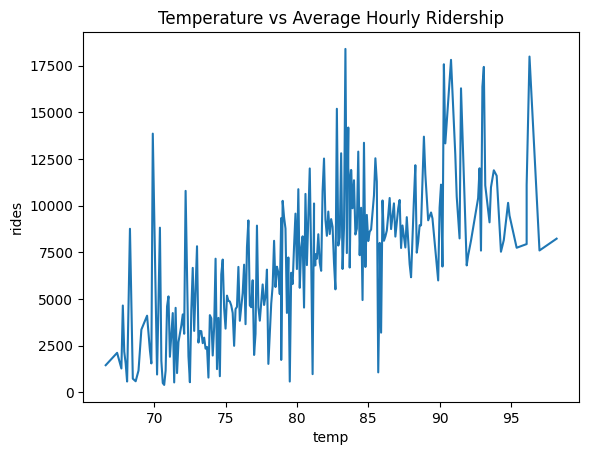

In [26]:
import seaborn as sns
temp_curve = merged_hourly.groupby('temp')['rides'].mean().reset_index()
sns.lineplot(data=temp_curve, x='temp', y='rides')
plt.title('Temperature vs Average Hourly Ridership')
plt.show()

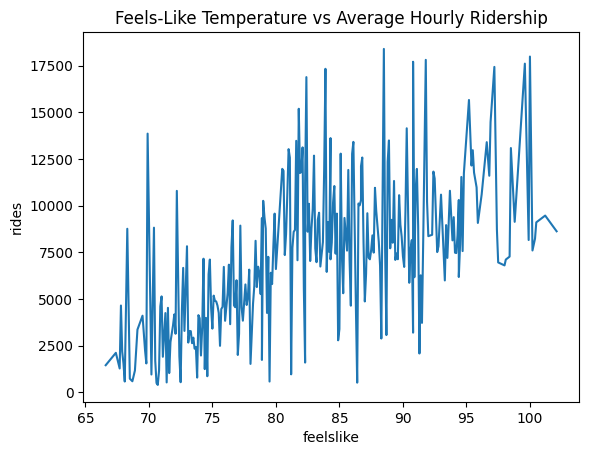

In [27]:
feels_curve = merged_hourly.groupby('feelslike')['rides'].mean().reset_index()
sns.lineplot(data=feels_curve, x='feelslike', y='rides')
plt.title('Feels-Like Temperature vs Average Hourly Ridership')
plt.show()

In [28]:
hourly_by_type = trips_clean.groupby(['date','hour','member_casual']).size().reset_index(name='rides')

In [29]:
merged_type_weather = hourly_by_type.merge(weather, on=['date','hour'], how='left')

In [30]:
casual = merged_type_weather[merged_type_weather['member_casual'] == 'casual']
member = merged_type_weather[merged_type_weather['member_casual'] == 'member']

casual_corr = casual[['rides','temp','feelslike','precip','cloudcover']].corr()['rides']
member_corr = member[['rides','temp','feelslike','precip','cloudcover']].corr()['rides']

casual_corr, member_corr

(rides         1.000000
 temp          0.487093
 feelslike     0.450608
 precip       -0.075034
 cloudcover   -0.011829
 Name: rides, dtype: float64,
 rides         1.000000
 temp          0.480558
 feelslike     0.467018
 precip       -0.058194
 cloudcover    0.009343
 Name: rides, dtype: float64)

In [31]:
merged_hourly['period'] = merged_hourly['hour'].apply(
    lambda h: 'commute' if h in [7,8,9,16,17,18] else 'midday'
)

In [32]:
commute = merged_hourly[merged_hourly['period'] == 'commute']
midday = merged_hourly[merged_hourly['period'] == 'midday']

commute_corr = commute[['rides','temp','feelslike','precip','cloudcover']].corr()['rides']
midday_corr = midday[['rides','temp','feelslike','precip','cloudcover']].corr()['rides']

commute_corr, midday_corr

(rides         1.000000
 temp          0.576402
 feelslike     0.589553
 precip       -0.123189
 cloudcover   -0.168168
 Name: rides, dtype: float64,
 rides         1.000000
 temp          0.533585
 feelslike     0.501895
 precip       -0.065479
 cloudcover    0.032791
 Name: rides, dtype: float64)

In [33]:
df = merged_hourly.copy()

In [34]:
df_test = df.merge(
    merged_trips[['date','hour','member_casual']],
    on=['date','hour'],
    how='left'
)

In [35]:
import scipy.stats as stats
import pandas as pd

table = pd.crosstab(df_test['cloudcover'], df_test['member_casual'])
chi2, p, dof, expected = stats.chi2_contingency(table)
p

np.float64(0.0)

In [36]:
from scipy.stats import pearsonr

pearsonr(df['temp'], df['rides'])
pearsonr(df['feelslike'], df['rides'])

PearsonRResult(statistic=np.float64(0.48093440403840787), pvalue=np.float64(2.5051280554135187e-44))

In [37]:
from scipy.stats import pearsonr
pearsonr(df['precip'], df['rides'])

PearsonRResult(statistic=np.float64(-0.06406887995010188), pvalue=np.float64(0.08073761159226))

In [38]:
from scipy.stats import pearsonr
pearsonr(df['cloudcover'], df['rides'])


PearsonRResult(statistic=np.float64(0.005050782791686285), pvalue=np.float64(0.890606964059324))

In [39]:
df = merged_hourly.copy()

In [40]:
from scipy.stats import norm
from math import atanh, sqrt

def fisher_compare(r1, r2, n1, n2):
    z1 = atanh(r1)
    z2 = atanh(r2)
    se = sqrt(1/(n1-3) + 1/(n2-3))
    z = (z1 - z2) / se
    p = 2 * (1 - norm.cdf(abs(z)))
    return z, p

df_casual = merged_trips[merged_trips['member_casual'] == 'casual']
df_member = merged_trips[merged_trips['member_casual'] == 'member']

n_casual = len(df_casual)
n_member = len(df_member)

corr = {
    "temp": (0.4871, 0.4806),
    "feelslike": (0.4506, 0.4670),
    "precip": (-0.0750, -0.0582),
    "cloudcover": (-0.0118, 0.0093)
}

for var, (r1, r2) in corr.items():
    z, p = fisher_compare(r1, r2, n_casual, n_member)
    print(var, z, p)

temp 7.716221414431655 1.199040866595169e-14
feelslike -18.88724464900959 0.0
precip -15.34274859071174 0.0
cloudcover -19.18456989293049 0.0


In [41]:
from math import atanh, sqrt
from scipy.stats import norm

def fisher_compare(r1, r2, n1, n2):
    z1 = atanh(r1)
    z2 = atanh(r2)
    se = sqrt(1/(n1-3) + 1/(n2-3))
    z = (z1 - z2) / se
    p = 2 * (1 - norm.cdf(abs(z)))
    return z, p

df_commute = df[df['period'] == 'commute']
df_midday  = df[df['period'] == 'midday']

n_commute = len(df_commute)
n_midday  = len(df_midday)

variables = {
    "temp": (0.5764, 0.5336),
    "feelslike": (0.5896, 0.5019),
    "precip": (-0.1232, -0.0655),
    "cloudcover": (-0.1682, 0.0328)
}

for var, (r1, r2) in variables.items():
    z, p = fisher_compare(r1, r2, n_commute, n_midday)
    print(var, z, p)

temp 0.7260456023945843 0.46781081504283195
feelslike 1.4688683738907793 0.14186849420517533
precip -0.6831703756465602 0.49449918969333595
cloudcover -2.377047400321191 0.017451845345780148
